In [9]:
# Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from utils import load_results
# Execute the loader and show a quick summary/preview
df_lre = load_results("../results/lre_jacobian", "*.json")
train_df = pd.read_json("../results/training/aggregated_results.json")
train_df = train_df.rename(columns={"weight_decay": "wd"})

# Plot style
sns.set_theme(style="ticks")

In [10]:
# Define thresholds for grouping
threshold_low = 0.4
threshold_high = 0.98

# Create masks for the two groups based on train_df
mask_g1 = (train_df['reverse_uni_acc'] < threshold_low)
mask_g2 = train_df['reverse_uni_acc'] > threshold_high

# Get the runs for each group
g1_runs = train_df[mask_g1][['wd', 'seed']]
g2_runs = train_df[mask_g2][['wd', 'seed']]

# Filter df based on Subfolder matching the runs
# Create tuples for matching
g1_tuples = set(zip(g1_runs['wd'], g1_runs['seed']))
g2_tuples = set(zip(g2_runs['wd'], g2_runs['seed']))

# df_bilinear, df_composition, df_transpose
df_g1 = df_lre[df_lre[['wd', 'seed']].apply(tuple, axis=1).isin(g1_tuples)].copy()
df_g2 = df_lre[df_lre[['wd', 'seed']].apply(tuple, axis=1).isin(g2_tuples)].copy()

# Add group labels
df_g1['group'] = 'Reversal Cursed'
df_g2['group'] = 'Not Reversal Cursed'
# Combine into one dataframe if needed
df_lre = pd.concat([df_g1, df_g2], ignore_index=True)

In [11]:
len(df_lre['beta'].unique())

9

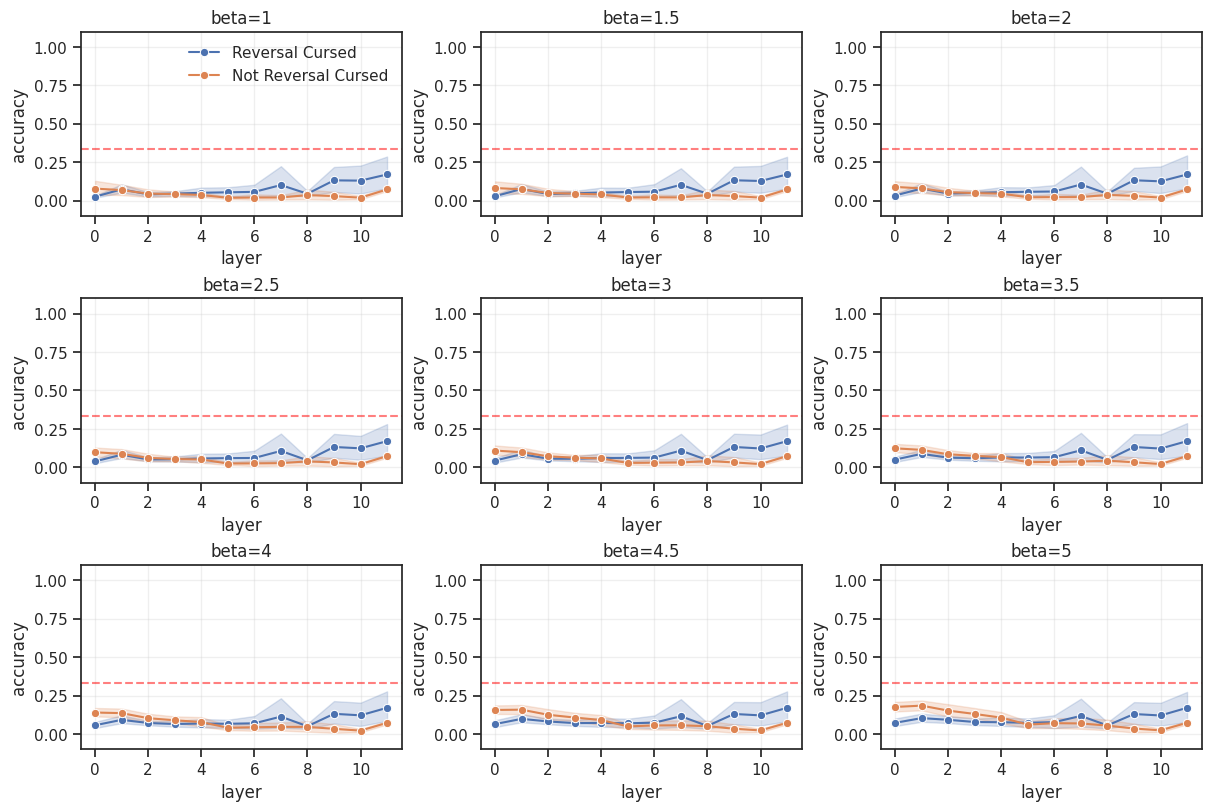

In [12]:
sns.set_theme(style="ticks")
fig, ax = plt.subplots(3, 3, figsize=(12, 8), constrained_layout=True)

for beta in df_lre['beta'].unique():
    # Plot with the corrected data
    subset = df_lre[df_lre['beta'] == beta]
    # map this beta to a subplot in the 3x3 grid and plot
    betas = sorted(df_lre['beta'].unique())
    idx = betas.index(beta)
    if idx >= 9:
        break
    a = ax[idx // 3, idx % 3]

    # plot 'overall' relation per layer, split by group
    to_plot = subset[subset['relation'] == 'overall']
    sns.lineplot(data=to_plot, x='layer', y='accuracy', hue='group', marker='o', ax=a)
    a.axhline(1/3, color='red', linestyle='--', alpha=0.5)  # chance level

    a.set_title(f'beta={beta:g}')
    a.set_xlabel('layer')
    a.set_ylabel('accuracy')
    a.set_ylim(-0.1, 1.1)
    a.grid(True, alpha=0.3)

    # show legend only on the first subplot
    leg = a.get_legend()
    if idx == 0:
        if leg:
            leg.set_title('')
            leg.set_frame_on(False)
    else:
        if leg:
            leg.remove()
    # ax.legend(title_fontsize='13', fontsize='10', frameon=False)
    # ax.set_title('Top-1 accuracy (translational) vs layer')
    # ax.set_xlabel('layer')
    # ax.set_ylabel('accuracy')
    # a.set_ylim(-0.1, 1.1)
    # ax.grid(True, alpha=0.3)


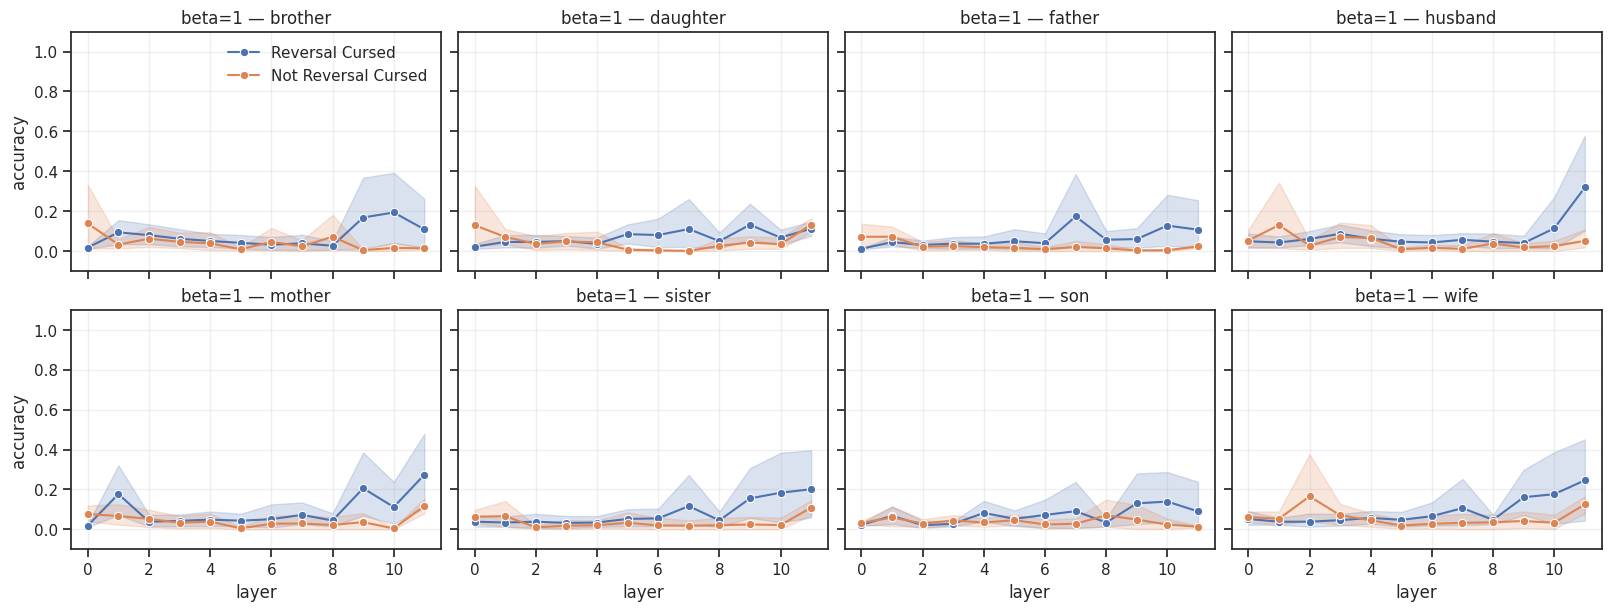

In [13]:
#
beta_sel = 1
rel_subset = df_lre[(df_lre['beta'] == beta_sel) & (df_lre['relation'] != 'overall')].copy()

relations = sorted(rel_subset['relation'].unique())
groups_order = ['Reversal Cursed', 'Not Reversal Cursed']

fig_rel, axes_rel = plt.subplots(2, 4, figsize=(16, 6), constrained_layout=True, sharey=True, sharex=True)
axes_rel = axes_rel.flatten()

for i, rel in enumerate(relations):
    ax = axes_rel[i]
    df_rel = rel_subset[rel_subset['relation'] == rel]
    
    sns.lineplot(data=df_rel, x='layer', y='accuracy', hue='group', hue_order=groups_order, marker='o', ax=ax)
    
    ax.set_title(f'beta={beta_sel:g} — {rel}')
    ax.set_xlabel('layer')
    ax.set_ylabel('accuracy')
    ax.set_ylim(-0.1, 1.1)
    ax.grid(True, alpha=0.3)
    
    leg = ax.get_legend()
    # Show legend only on the first subplot
    if i == 0:
        if leg:
            leg.set_title('')
            leg.set_frame_on(False)
    else:
        if leg:
            leg.remove()

# Hide any unused subplots
for j in range(i + 1, len(axes_rel)):
    axes_rel[j].set_visible(False)

/tmp/ipykernel_52162/2374869674.py:75: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


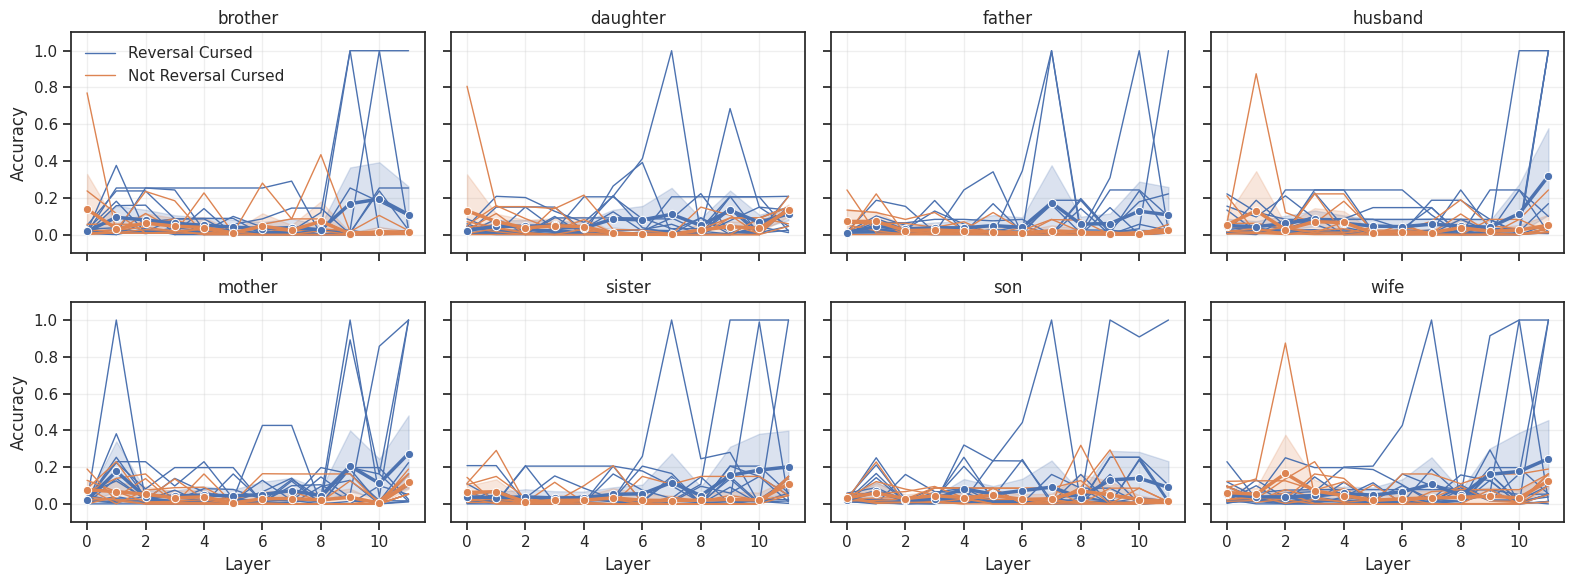

In [14]:
# Create spaghetti plots for each relation
# Each line represents a single run (wd, seed combination)

# Prepare data for spaghetti plot
# rel_subset = df_lre[(df_lre['beta'] == beta_sel) & (df_lre['relation'] != 'overall')].copy()


df_spaghetti = df_lre[(df_lre['beta'] == beta_sel) & (df_lre['relation'] != 'overall')].copy()
# Create a unique identifier for each run to be used in the 'units' parameter
df_spaghetti['run_id'] = df_spaghetti['wd'].astype(str) + '_' + df_spaghetti['seed'].astype(str)

# Create the plot grid
fig_spaghetti, axes_spaghetti = plt.subplots(2, 4, figsize=(16, 6), constrained_layout=True, sharey=True, sharex=True)
axes_spaghetti = axes_spaghetti.flatten()

# Palette for the groups
palette = sns.color_palette()
group_colors = {
    'Reversal Cursed': palette[0],
    'Not Reversal Cursed': palette[1]
}

for i, rel in enumerate(relations):
    ax = axes_spaghetti[i]
    df_rel = df_spaghetti[df_spaghetti['relation'] == rel]
    
    # Plot spaghetti lines for each run
    sns.lineplot(
        data=df_rel, 
        x='layer', 
        y='accuracy', 
        hue='group', 
        hue_order=groups_order,
        units='run_id', 
        estimator=None, 
        lw=1.0, 
        palette=group_colors,
        ax=ax
    )
    
    # Overlay the mean lineplot
    sns.lineplot(
        data=df_rel, 
        x='layer', 
        y='accuracy', 
        hue='group',
        hue_order=groups_order,
        marker='o', 
        ax=ax,
        legend=False, # The legend is already created by the first plot
        palette=group_colors,
        lw=2.5
    )
    
    ax.set_title(f'{rel}')
    ax.set_xlabel('Layer')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(-0.1, 1.1)
    ax.grid(True, alpha=0.3)
    
    leg = ax.get_legend()
    # Show legend only on the first subplot
    if i == 0:
        if leg:
            leg.set_title('')
            leg.set_frame_on(False)
    else:
        if leg:
            leg.remove()

# Hide any unused subplots
for j in range(i + 1, len(axes_spaghetti)):
    axes_spaghetti[j].set_visible(False)

plt.tight_layout()
plt.savefig("SM-translational_spaghetti.pdf", bbox_inches='tight')

In [15]:
df_lre

,wd,seed,layer,relation,beta,accuracy,group
0,0.0,0,0,husband,1.0,0.010667,Reversal Cursed
1,0.0,0,0,wife,1.0,0.024000,Reversal Cursed
2,0.0,0,0,father,1.0,0.013333,Reversal Cursed
3,0.0,0,0,mother,1.0,0.016000,Reversal Cursed
4,0.0,0,0,sister,1.0,0.008000,Reversal Cursed
...,...,...,...,...,...,...,...
21379,6.0,1,11,sister,5.0,0.149333,Not Reversal Cursed
21380,6.0,1,11,brother,5.0,0.005333,Not Reversal Cursed
21381,6.0,1,11,son,5.0,0.010667,Not Reversal Cursed
21382,6.0,1,11,daughter,5.0,0.149333,Not Reversal Cursed


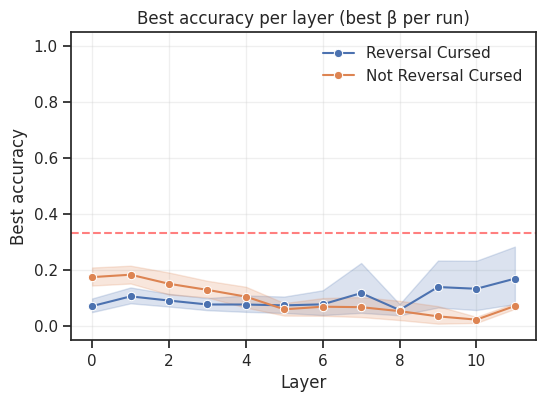

In [16]:
# Get best accuracy (over β) per (wd, seed, layer) for relation=="overall"
df_overall = df_lre[df_lre['relation'] == 'overall'].copy()
idx_best = df_overall.groupby(['wd', 'seed', 'layer'])['accuracy'].idxmax()
df_best_layer = df_overall.loc[idx_best].reset_index(drop=True)

# Average the best accuracy across runs, keep groups separate
df_best_layer_mean = (
    df_best_layer
    .groupby(['layer', 'group'], as_index=False)['accuracy']
    .mean()
)

# Plot best accuracy vs. layer
fig_best_layer, ax_best_layer = plt.subplots(figsize=(6, 4))
sns.lineplot(
    data=df_best_layer,
    x='layer',
    y='accuracy',
    hue='group',
    hue_order=groups_order,
    marker='o',
    palette=group_colors,
    ax=ax_best_layer
)
ax_best_layer.set_title('Best accuracy per layer (best β per run)')
ax_best_layer.set_xlabel('Layer')
ax_best_layer.set_ylabel('Best accuracy')
ax_best_layer.axhline(1/3, color='red', linestyle='--', alpha=0.5)  # chance level
ax_best_layer.set_ylim(-0.05, 1.05)
ax_best_layer.grid(True, alpha=0.3)

# Optional: tidy legend
leg = ax_best_layer.get_legend()
if leg:
    leg.set_title('')
    leg.set_frame_on(False)
plt.show()